In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker
from scipy import stats
import math
from matplotlib.ticker import EngFormatter

In [20]:
hp = pd.read_csv("dataset_2.csv")

In [21]:
hp = hp.dropna()
hp.isnull().sum()

Area_SqFt        0
Rooms            0
Build_Year       0
Location         0
Street_Type      0
Furnishing       0
Property_Type    0
Has_Pool         0
Price            0
dtype: int64

In [22]:
l = hp["Location"]
a = l.value_counts()

Text(0, 0.5, 'Properties Count')

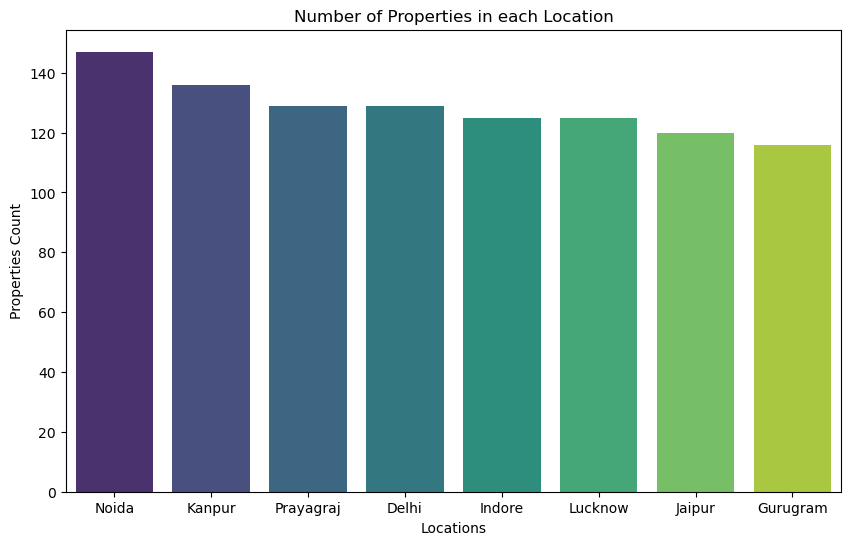

In [23]:
plt.figure(figsize=(10,6))
sns.barplot(x=a.index, y=a.values, hue=a.index, palette='viridis')
plt.title("Number of Properties in each Location")
plt.xlabel('Locations')
plt.ylabel('Properties Count')

Text(0.5, 1.0, 'Number of Furnished Properties in each Location')

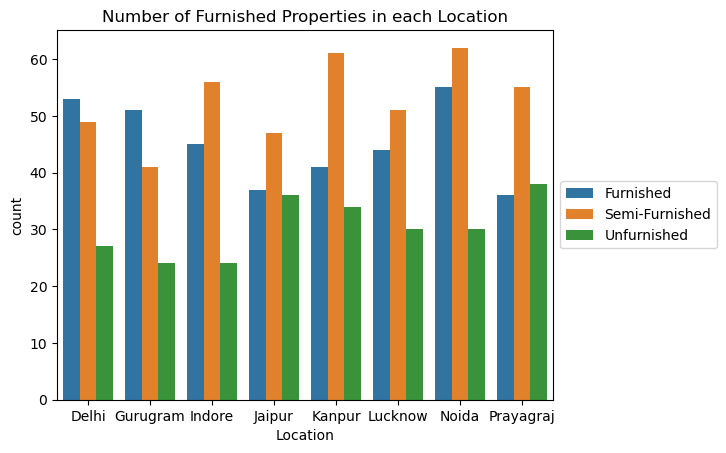

In [24]:
fi = hp.groupby(["Location","Furnishing"]).size()
df = fi.reset_index(name='count')
sns.barplot(df, x="Location", y="count", hue="Furnishing")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("Number of Furnished Properties in each Location")

Text(0.5, 1.0, 'Kind of Properties in each Location')

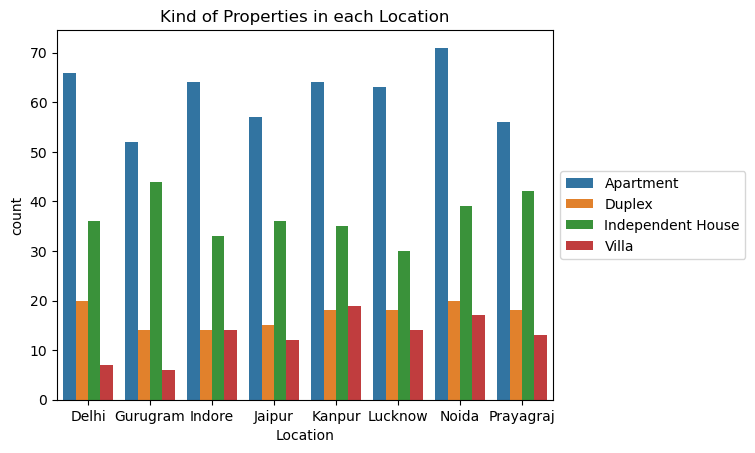

In [25]:
ap = hp.groupby(["Location","Property_Type"]).size()
df = ap.reset_index(name='count')
sns.barplot(df, x="Location", y="count", hue="Property_Type")
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title("Kind of Properties in each Location")

Text(0.5, 1.0, 'Average Properties Price per Location')

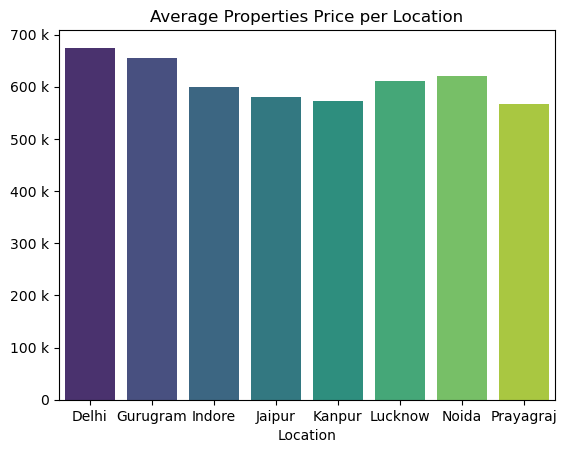

In [26]:
price=hp.groupby("Location")["Price"].mean()

ax = sns.barplot(x=price.index, y=price.values, hue=price.index, palette='viridis')
ax.yaxis.set_major_formatter(EngFormatter())
plt.title("Average Properties Price per Location")

<Axes: xlabel='Area_SqFt', ylabel='Price'>

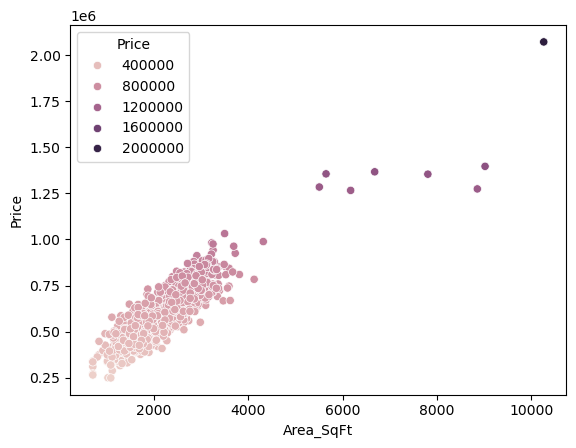

In [27]:
ndf = hp.loc[:,["Area_SqFt","Price"]]
sns.scatterplot(data=ndf, x="Area_SqFt", y="Price", hue="Price")

75.0% of the variance can be explained my the model
There is a strong positive correlation: r = 0.86


<Axes: xlabel='Area_SqFt', ylabel='Price'>

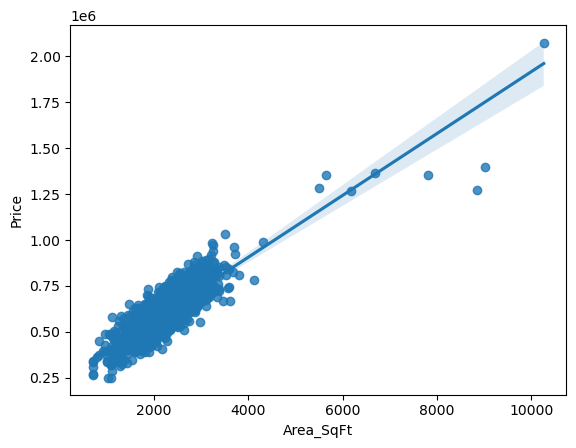

In [45]:
mean_x = ndf.loc[:,"Area_SqFt"].mean()
mean_y = ndf.loc[:,"Price"].mean()

Sxx = ((ndf["Area_SqFt"] - mean_x) ** 2).sum()
Sxy = ((ndf["Area_SqFt"] - mean_x) * (ndf["Price"] - mean_y)).sum()
Syy = ((ndf["Price"] - mean_y) ** 2).sum()

#Slope of the regression
m = Sxy/Sxx
# For each of 1 sqare feet the price increases 0.99
b = mean_y - (m*mean_x)

# Sum of squares of the Regression
SSr = ((((m*ndf["Area_SqFt"]) + b)- mean_y) ** 2).sum()
# Sum of squares Error
SSe = ((ndf["Price"] - ((m*ndf["Area_SqFt"]) + b)) ** 2).sum()


# Cofficent of determination
r2 = SSr/Syy
print(f"{round(r2,2) * 100}% of the variance can be explained my the model")
r = math.sqrt(r2)

if r > 0.7:
    print(f"There is a strong positive correlation: r = {round(r,2)}")
elif r > 0.4:
    print(f"There is a moderate positive correlation: r = {round(r,2)}")
elif r < -0.7:
    print(f"There is a strong negative correlation: r = {round(r,2)}")
else:
    print(f"There is a weak correlation: r = {round(r,2)}")

sns.regplot(data=ndf, x="Area_SqFt", y="Price")